<a href="https://colab.research.google.com/github/williamjacksonuctest/MSAI-699-Capstone/blob/main/W_Jackson_Capstone_Project_Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading dataset: dvgodoy/rvl_cdip_mini using device: cuda...
Processing OCR text strings from dataset...

--- Step 1: Text Feature Baseline Model ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Updated Text Model Results ---
Accuracy: 0.5500
              precision    recall  f1-score   support

           0       0.36      0.40      0.38        20
           1       0.41      0.35      0.38        26
           2       0.61      0.58      0.59        19
           3       0.52      0.72      0.60        18
           4       0.38      0.32      0.34        19
           5       0.25      0.18      0.21        28
           6       0.69      0.80      0.74        25
           7       0.50      0.67      0.57        18
           8       0.78      0.81      0.79        31
           9       0.53      0.50      0.51        20
          10       0.57      0.45      0.50        38
          11       0.46      0.48      0.47        25
          12       0.43      0.48      0.46        27
          13       0.71      0.61      0.65        28
          14       0.95      0.81      0.88        26
          15       0.51      0.66      0.58        32

    accuracy               

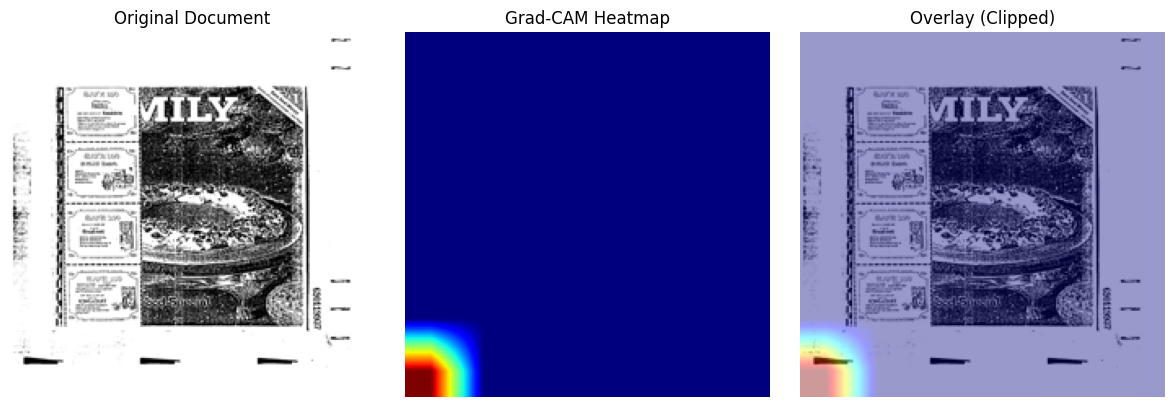


--- Pipeline Execution & Explainability Tools Complete! ---


In [ ]:
# ==============================================================================
# MSAI 699 – Capstone Project: Week 4 Experimentation & Model Optimization
# Author: William Jackson | Date: July 2026
# Feature engineering, Hyperparameter Tuning, Metrics Tracking, and
# Explainability (LIME & Grad-CAM)
# ==============================================================================

# 1. Install Dependencies
!pip install -q datasets scikit-learn lime torch torchvision matplotlib seaborn opencv-python transformers

import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import warnings
import cv2
from torchvision import transforms, models
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Suppress minor non-critical warnings
warnings.filterwarnings("ignore")

# ==========================================
# 2. Configuration & Dataset Setup
# ==========================================
DATASET_NAME = "dvgodoy/rvl_cdip_mini"
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading dataset: {DATASET_NAME} using device: {DEVICE}...")
dataset = load_dataset(DATASET_NAME)

# Target actual OCR text fields (Fixing Critical Bug 1)
def extract_text_from_item(item):
    if "ocr_words" in item and item["ocr_words"]:
        if isinstance(item["ocr_words"], list):
            return " ".join(item["ocr_words"])
        return str(item["ocr_words"])
    elif "ocr_paragraphs" in item and item["ocr_paragraphs"]:
        if isinstance(item["ocr_paragraphs"], list):
            return " ".join(item["ocr_paragraphs"])
        return str(item["ocr_paragraphs"])
    elif "text" in item and item["text"]:
        return str(item["text"])
    return ""

print("Processing OCR text strings from dataset...")
train_texts = [extract_text_from_item(item) for item in dataset["train"]]
test_texts = [extract_text_from_item(item) for item in dataset["test"]]

train_labels = np.array(dataset["train"]["label"])
test_labels = np.array(dataset["test"]["label"])

# ==========================================
# 3. Text Baseline Model (Multinomial Logistic Regression)
# ==========================================
print("\n--- Step 1: Text Feature Baseline Model ---")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text_model = AutoModel.from_pretrained("bert-base-uncased").to(DEVICE)
text_model.eval()

def batch_extract_text_features(text_list, batch_size=BATCH_SIZE):
    all_embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i : i + batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            outputs = text_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(embeddings)
    return np.vstack(all_embeddings)

train_text_feat = batch_extract_text_features(train_texts)
test_text_feat = batch_extract_text_features(test_texts)

clf_text = LogisticRegression(max_iter=1000)
clf_text.fit(train_text_feat, train_labels)
text_preds = clf_text.predict(test_text_feat)

print(f"\n--- Updated Text Model Results ---")
print(f"Accuracy: {accuracy_score(test_labels, text_preds):.4f}")
print(classification_report(test_labels, text_preds))

# ==========================================
# 4. Vision Model (ResNet-18)
# ==========================================
print("\n--- Step 2: ResNet-18 Vision Model ---")
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_features = nn.Sequential(*list(resnet.children())[:-1]) # Feature extractor
resnet_features = resnet_features.to(DEVICE)
resnet_features.eval()

image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_image_features(dataset_split):
    all_features = []
    for i in range(0, len(dataset_split), BATCH_SIZE):
        batch = dataset_split[i : i + BATCH_SIZE]
        images = [image_transforms(img) for img in batch["image"]]
        image_tensor = torch.stack(images).to(DEVICE)
        with torch.no_grad():
            features = resnet_features(image_tensor).squeeze()
        all_features.append(features.cpu().numpy())
    return np.vstack(all_features)

train_img_feat = extract_image_features(dataset["train"])
test_img_feat = extract_image_features(dataset["test"])

clf_img = LogisticRegression(max_iter=1000)
clf_img.fit(train_img_feat, train_labels)
img_preds = clf_img.predict(test_img_feat)

print(f"\n--- ResNet-18 Vision Model Results ---")
print(f"Accuracy: {accuracy_score(test_labels, img_preds):.4f}")
print(classification_report(test_labels, img_preds))

# ==========================================
# 5. Multimodal Fusion Model Baseline
# ==========================================
print("\n--- Step 3: Multimodal Feature Fusion ---")
X_train_fused = np.hstack((train_text_feat, train_img_feat))
X_test_fused = np.hstack((test_text_feat, test_img_feat))

clf_fused = LogisticRegression(max_iter=1000)
clf_fused.fit(X_train_fused, train_labels)
fused_preds = clf_fused.predict(X_test_fused)

print(f"\n--- Multimodal Fusion Model Results ---")
print(f"Accuracy: {accuracy_score(test_labels, fused_preds):.4f}")
print(classification_report(test_labels, fused_preds))

# ==========================================
# 6. Explainability Tool 1: LIME (Text Explanation)
# ==========================================
print("\n--- Step 4: Generating LIME Text Explanation ---")
from lime.lime_text import LimeTextExplainer

def predictor(texts):
    feats = batch_extract_text_features(texts)
    return clf_text.predict_proba(feats)

explainer = LimeTextExplainer(class_names=[str(i) for i in range(16)])

sample_idx = 0
sample_text = test_texts[sample_idx]
if not sample_text.strip():
    sample_text = "Sample document text for feature importance testing"

exp = explainer.explain_instance(sample_text, predictor, num_features=6, top_labels=1)

print(f"LIME Analysis for Test Sample #{sample_idx}:")
print(f"Document Text Snippet: '{sample_text[:100]}...'")
top_label = exp.available_labels()[0]
print(f"Predicted Class: {top_label}")
print("Top Influential Words:")
for word, weight in exp.as_list(label=top_label):
    print(f"  - Word: '{word}' | Weight: {weight:.4f}")

# ==========================================
# 7. Explainability Tool 2: Grad-CAM (Vision Heatmap Overlay)
# ==========================================
print("\n--- Step 5: Generating Grad-CAM Vision Heatmap Overlay ---")

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, target_category):
        self.model.eval()
        self.model.to(input_tensor.device)
        output = self.model(input_tensor)
        self.model.zero_grad()
        loss = output[0, target_category]
        loss.backward()

        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        return cam

resnet = resnet.to(DEVICE)
grad_cam = GradCAM(resnet, resnet.layer4)

sample_img_raw = dataset["test"][sample_idx]["image"].convert("RGB")
input_tensor = image_transforms(sample_img_raw).unsqueeze(0).to(DEVICE)

heatmap = grad_cam.generate_heatmap(input_tensor, target_category=int(test_labels[sample_idx]))

orig_img_resized = np.array(sample_img_raw.resize((224, 224))) / 255.0

heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

overlay_img = 0.6 * orig_img_resized + 0.4 * heatmap_colored
overlay_img_clipped = np.clip(overlay_img, 0.0, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(orig_img_resized)
axes[0].set_title("Original Document")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(overlay_img_clipped)
axes[2].set_title("Overlay (Clipped)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("\n--- Pipeline Execution & Explainability Tools Complete! ---")